In [1]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = X.copy()
df["target"] = y

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:
df.shape

(303, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [5]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
print(df["target"].value_counts())

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [7]:
df["target"] = (df["target"] > 0).astype(int)
print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [8]:
print(df["ca"].value_counts())
print(df["thal"].value_counts())

ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64
thal
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64


In [9]:
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [10]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [11]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [12]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [13]:
df[numerical_features].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [14]:
for col in categorical_features:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
1    206
0     97
Name: count, dtype: int64

 cp
cp
4    144
3     86
2     50
1     23
Name: count, dtype: int64

 fbs
fbs
0    258
1     45
Name: count, dtype: int64

 restecg
restecg
0    151
2    148
1      4
Name: count, dtype: int64

 exang
exang
0    204
1     99
Name: count, dtype: int64

 slope
slope
1    142
2    140
3     21
Name: count, dtype: int64

 ca
ca
0.0    180
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

 thal
thal
3.0    168
7.0    117
6.0     18
Name: count, dtype: int64


In [15]:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    164
1    139
Name: count, dtype: int64
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [16]:
df.corr(numeric_only=True)["target"].sort_values()

,target
thalach,-0.417167
fbs,0.025264
chol,0.085164
trestbps,0.150825
restecg,0.169202
age,0.223120
sex,0.276816
slope,0.339213
cp,0.414446
oldpeak,0.424510


In [17]:
X = df.drop("target", axis=1)

y = df["target"]

In [18]:
print(X.shape)
print(y.shape)

(303, 13)
(303,)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

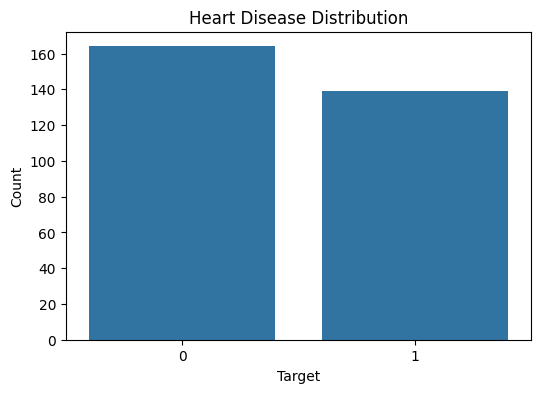

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

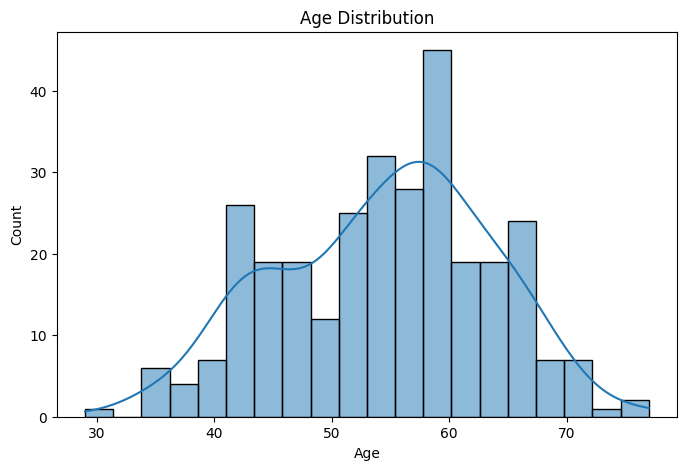

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

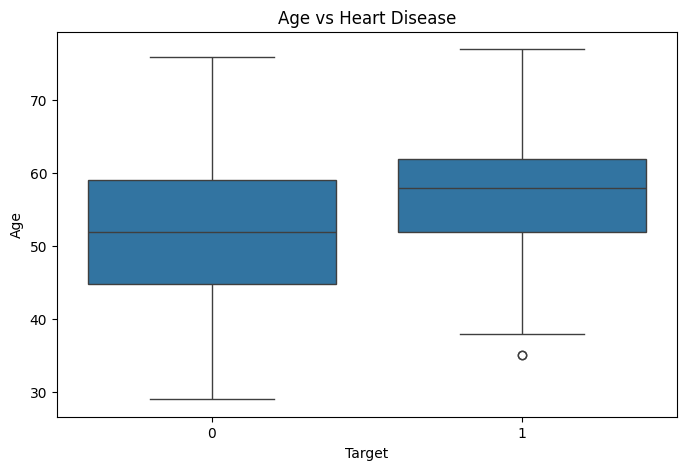

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Target")
plt.ylabel("Age")

plt.show()

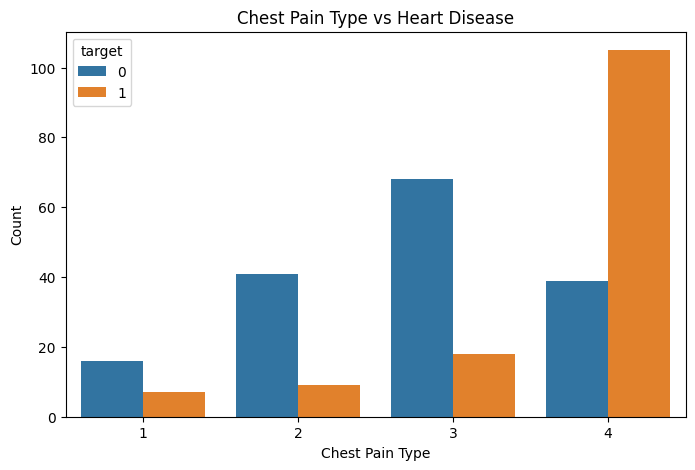

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

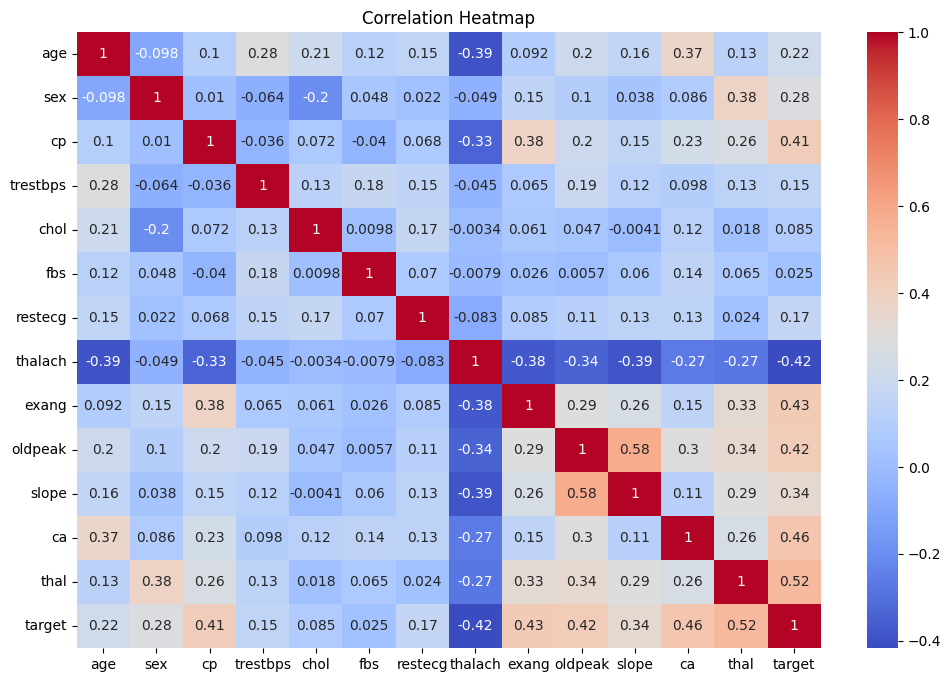

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X = df.drop("target", axis=1)
y = df["target"]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [26]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8852459016393442


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28  5]
 [ 2 26]]


In [30]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8387096774193549


In [31]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9285714285714286


In [32]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1:", f1)

F1: 0.8813559322033898


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



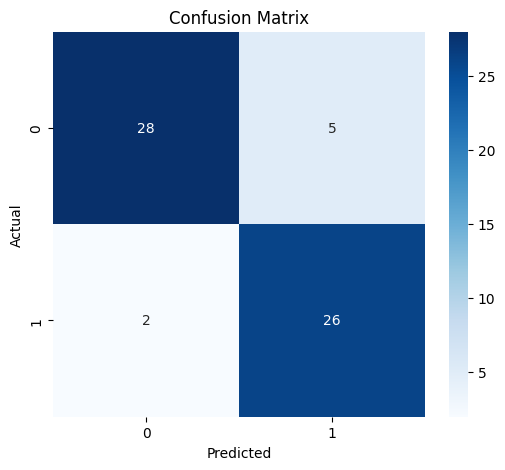

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [37]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [38]:
y_pred_tree = tree_model.predict(X_test)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.68      0.82      0.74        28

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61



In [40]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

Accuracy: 0.7377049180327869


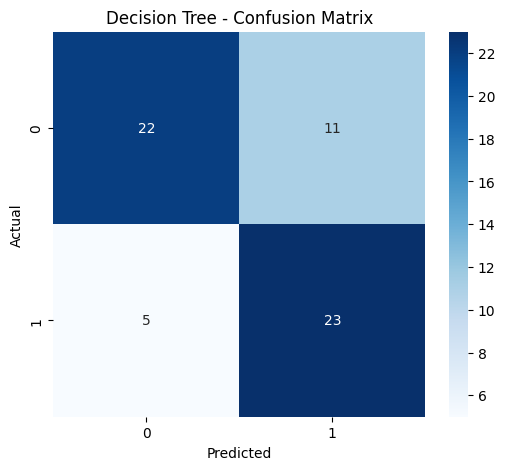

In [41]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [43]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8524590163934426


In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [46]:
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV Recall:")
print(grid_search.best_score_)
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best CV Recall:
0.78300395256917


In [47]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [48]:
best_rf.named_steps["classifier"]

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [49]:
importances = best_rf.named_steps["classifier"].feature_importances_

In [50]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

In [51]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [52]:
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

In [53]:
importance_df.head(10)

,feature,importance
25,cat__thal_3.0,0.118012
21,cat__ca_0.0,0.099394
27,cat__thal_7.0,0.088833
10,cat__cp_4,0.085163
4,num__oldpeak,0.075207
3,num__thalach,0.074267
0,num__age,0.063249
2,num__chol,0.055687
1,num__trestbps,0.049319
16,cat__exang_0,0.038035


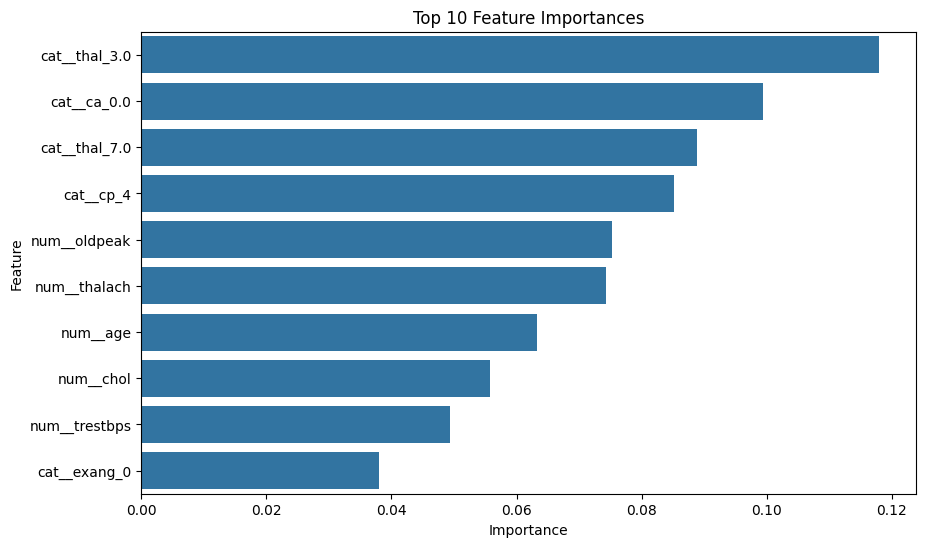

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

y_prob_lr = model.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", auc_lr)

Logistic Regression ROC-AUC: 0.9664502164502166


In [56]:
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.9480519480519481


In [57]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ],
    "ROC-AUC": [
        auc_lr,
        roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        auc_rf
    ]
})

results

,Model,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.885246,0.928571,0.881356,0.966450
1,Decision Tree,0.737705,0.821429,0.741935,0.744048
2,Random Forest,0.852459,0.892857,0.847458,0.943182
3,Tuned Random Forest,0.868852,0.928571,0.866667,0.948052


In [58]:
import joblib

joblib.dump(model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [59]:
loaded_model = joblib.load("heart_disease_model.pkl")

test_prediction = loaded_model.predict(X_test[:5])

print(test_prediction)

[0 1 0 0 0]
